# CTC Detection — Geneformer Fine-tuning
Fine-tunes Geneformer for circulating tumor cell (CTC) detection in scRNA-seq data.
Targets EpCAM-low CTCs missed by CellSearch.

**Runtime:** GPU (T4 or better). Runtime > Change runtime type > T4 GPU

## 1. Check GPU

In [1]:
!git clone https://github.com/gabufle/ctc-detect.git
%cd ctc-detect
!pip install transformers==4.41.0 peft==0.11.0 accelerate datasets scanpy anndata pyensembl mygene -q
!pyensembl install --release 109 --species homo_sapiens

Cloning into 'ctc-detect'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 60 (delta 15), reused 55 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 25.17 MiB | 13.70 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/ctc-detect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# copy h5ad from drive to working directory
!cp /content/drive/MyDrive/ctc_merged_processed.h5ad data/processed/

Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/ctc_merged_processed.h5ad': No such file or directory


In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

## 2. Install dependencies

In [3]:
#%%capture
!pip install scanpy anndata peft accelerate datasets scikit-learn umap-learn matplotlib seaborn
!git clone https://huggingface.co/ctheodoris/Geneformer
!pip install --no-deps ./Geneformer
!pip install loompy tdigest -q
!pip install mygene -q

Cloning into 'Geneformer'...
remote: Enumerating objects: 1255, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1255 (delta 1), reused 0 (delta 0), pack-reused 1247 (from 1)
Receiving objects: 100% (1255/1255), 4.80 MiB | 5.86 MiB/s, done.
Resolving deltas: 100% (810/810), done.
Filtering content: 100% (24/24), 3.32 GiB | 55.89 MiB/s, done.
Processing ./Geneformer
  Preparing metadata (setup.py) ... done
  Created wheel for geneformer: filename=geneformer-0.1.0-py3-none-any.whl size=2980779 sha256=ef0f784dd6bc64314038b3aa30d93cc62a6836ea78b55cab50abf75d4d61bbe4
  Stored in directory: /tmp/pip-ephem-wheel-cache-awqf672x/wheels/95/5f/7b/21b3e02d96d5ebb21e96daef211802ff0748d29161b05454a8
Successfully built geneformer
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Pr

## 3. Mount Google Drive and load data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('data/processed', exist_ok=True)
os.makedirs('results/checkpoints/best_model', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

# Copy h5ad from Drive
!cp /content/drive/MyDrive/ctc_merged_processed.h5ad data/processed/
print('h5ad loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/MyDrive/ctc_merged_processed.h5ad': No such file or directory
h5ad loaded


## 4. Load and inspect data

In [5]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad('/content/drive/MyDrive/CTC - testing/ctc_merged_processed.h5ad')
print('Cells:', adata.n_obs)
print('Genes:', adata.n_vars)
print('Columns:', adata.obs.columns.tolist())
print()
print('CTC breakdown:')
print(adata.obs['is_ctc'].value_counts())
print()
print('EpCAM status breakdown:')
print(adata.obs['epcam_status'].value_counts())

Cells: 11156
Genes: 7637
Columns: ['sample', 'is_ctc', 'cell_source', 'ctc_identification_method', 'epcam_status', 'epcam_expression', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch']

CTC breakdown:
is_ctc
True     8458
False    2698
Name: count, dtype: int64

EpCAM status breakdown:
epcam_status
low     11045
high      111
Name: count, dtype: int64


## 5. Tokenize for Geneformer

In [6]:
# Geneformer needs Ensembl IDs - convert gene symbols
# First check what format our genes are in
print('First 10 gene names:', adata.var_names[:10].tolist())
print('Gene name format looks like Ensembl?', adata.var_names[0].startswith('ENSG'))

First 10 gene names: ['LINC00115', 'NOC2L', 'ISG15', 'SDF4', 'UBE2J2', 'ACAP3', 'AURKAIP1', 'CCNL2', 'MRPL20', 'SSU72']
Gene name format looks like Ensembl? False


In [7]:
from pyensembl import EnsemblRelease
genome = EnsemblRelease(109)

def symbol_to_ensembl(symbol):
    try:
        genes = genome.genes_by_name(symbol)
        if genes:
            return genes[0].gene_id
        return None
    except:
        return None

print('Converting gene symbols to Ensembl IDs...')
adata.var['ensembl_id'] = [symbol_to_ensembl(g) for g in adata.var_names]

# Report conversion rate
n_converted = adata.var['ensembl_id'].notna().sum()
print(f'Converted: {n_converted}/{adata.n_vars} genes ({100*n_converted/adata.n_vars:.1f}%)')

# Filter to converted genes only
adata = adata[:, adata.var['ensembl_id'].notna()].copy()
adata.var_names = adata.var['ensembl_id'].values
print(f'Genes after filtering: {adata.n_vars}')
print('First 5 Ensembl IDs:', adata.var_names[:5].tolist())

Converting gene symbols to Ensembl IDs...
Converted: 7456/7637 genes (97.6%)
Genes after filtering: 7456
First 5 Ensembl IDs: ['ENSG00000225880', 'ENSG00000188976', 'ENSG00000187608', 'ENSG00000078808', 'ENSG00000160087']


In [8]:
import os
for root, dirs, files in os.walk('./Geneformer'):
    for f in files:
        print(os.path.join(root, f))

./Geneformer/config.json
./Geneformer/.pre-commit-config.yaml
./Geneformer/setup.py
./Geneformer/.gitattributes
./Geneformer/model.safetensors
./Geneformer/generation_config.json
./Geneformer/.gitignore
./Geneformer/training_args.bin
./Geneformer/requirements.txt
./Geneformer/.readthedocs.yaml
./Geneformer/MANIFEST.in
./Geneformer/README.md
./Geneformer/Geneformer-V2-316M/config.json
./Geneformer/Geneformer-V2-316M/model.safetensors
./Geneformer/Geneformer-V2-316M/generation_config.json
./Geneformer/Geneformer-V2-316M/training_args.bin
./Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/rng_state.pth
./Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/config.json
./Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/trainer_state.json
./Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/optimizer.pt
./Geneformer/fine_tuned_models/Geneformer-V1-10M

In [9]:
import pickle
import numpy as np
from scipy.sparse import issparse

# Load Geneformer V2 vocabulary files
with open('./Geneformer/geneformer/gene_median_dictionary_gc104M.pkl', 'rb') as f:
    gene_median_dict = pickle.load(f)

with open('./Geneformer/geneformer/token_dictionary_gc104M.pkl', 'rb') as f:
    token_dict = pickle.load(f)

print(f'Vocab size: {len(token_dict)} tokens')
print(f'Genes in median dict: {len(gene_median_dict)}')

def tokenize_cell(expression_vector, gene_names):
    if issparse(expression_vector):
        expression_vector = expression_vector.toarray().flatten()
    else:
        expression_vector = np.array(expression_vector).flatten()

    expressed_mask = expression_vector > 0
    expressed_genes = gene_names[expressed_mask]
    expressed_values = expression_vector[expressed_mask]

    normalized = []
    for gene, val in zip(expressed_genes, expressed_values):
        median = gene_median_dict.get(gene, None)
        if median and median > 0:
            normalized.append((gene, val / median))

    normalized.sort(key=lambda x: x[1], reverse=True)
    token_ids = [token_dict[g] for g, _ in normalized if g in token_dict]
    return token_ids

print('Tokenizing cells...')
gene_names = np.array(adata.var_names)
all_input_ids = []
all_lengths = []

for i in range(adata.n_obs):
    if i % 1000 == 0:
        print(f'  {i}/{adata.n_obs}')
    expr = adata.X[i]
    token_ids = tokenize_cell(expr, gene_names)
    all_input_ids.append(token_ids)
    all_lengths.append(len(token_ids))

print(f'Done. Mean length: {np.mean(all_lengths):.0f} | Max: {max(all_lengths)} | Min: {min(all_lengths)}')

Vocab size: 20275 tokens
Genes in median dict: 42005
Tokenizing cells...
  0/11156
  1000/11156
  2000/11156
  3000/11156
  4000/11156
  5000/11156
  6000/11156
  7000/11156
  8000/11156
  9000/11156
  10000/11156
  11000/11156
Done. Mean length: 1093 | Max: 4280 | Min: 144


## 6. Split, pad and prepare datasets

In [10]:
from datasets import Dataset
import pandas as pd

# Build dataset from tokenized cells
dataset_dict = {
    'input_ids': all_input_ids,
    'length': all_lengths,
    'label': [int(x) for x in adata.obs['is_ctc'].values],
    'is_ctc': [int(x) for x in adata.obs['is_ctc'].values],
    'epcam_status': [str(x) for x in adata.obs['epcam_status'].values],
}

full_ds = Dataset.from_dict(dataset_dict)
print(full_ds)
print(f'CTCs: {sum(full_ds["label"])} | Normal: {len(full_ds) - sum(full_ds["label"])}')

Dataset({
    features: ['input_ids', 'length', 'label', 'is_ctc', 'epcam_status'],
    num_rows: 11156
})
CTCs: 8458 | Normal: 2698


In [11]:
from datasets import DatasetDict

# Stratified split
ctc_idx    = [i for i, x in enumerate(full_ds['label']) if x == 1]
normal_idx = [i for i, x in enumerate(full_ds['label']) if x == 0]
np.random.seed(42)
np.random.shuffle(ctc_idx)
np.random.shuffle(normal_idx)

def split_indices(idx, train=0.7, val=0.15):
    n = len(idx)
    return idx[:int(n*train)], idx[int(n*train):int(n*(train+val))], idx[int(n*(train+val)):]

ctc_tr, ctc_va, ctc_te       = split_indices(ctc_idx)
norm_tr, norm_va, norm_te    = split_indices(normal_idx)

train_idx = sorted(ctc_tr + norm_tr)
val_idx   = sorted(ctc_va + norm_va)
test_idx  = sorted(ctc_te + norm_te)

train_ds = full_ds.select(train_idx)
val_ds   = full_ds.select(val_idx)
test_ds  = full_ds.select(test_idx)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Train CTCs: {sum(train_ds["label"])} | Normal: {len(train_ds) - sum(train_ds["label"])}')

Train: 7808 | Val: 1674 | Test: 1674
Train CTCs: 5920 | Normal: 1888


In [12]:
# Pad and truncate to 2048 (Geneformer pretraining max)
MAX_LENGTH = 2048

def pad_and_truncate(example):
    ids = example['input_ids'][:MAX_LENGTH]
    length = len(ids)
    example['input_ids'] = ids + [0] * (MAX_LENGTH - length)
    example['attention_mask'] = [1] * length + [0] * (MAX_LENGTH - length)
    example['length'] = length
    return example

train_ds = train_ds.map(pad_and_truncate, num_proc=2)
val_ds   = val_ds.map(pad_and_truncate, num_proc=2)
test_ds  = test_ds.map(pad_and_truncate, num_proc=2)

# Set torch format
cols = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

print('Sequence length check:', len(train_ds[0]['input_ids']))
print('Ready for training')

Map (num_proc=2):   0%|          | 0/7808 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1674 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1674 [00:00<?, ? examples/s]

Sequence length check: 2048
Ready for training


## 7. Load model and apply LoRA

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.path.exists('/content/drive/MyDrive/ctc_tokenized_train'))
print(os.path.exists('/content/drive/MyDrive/ctc_tokenized_val'))
print(os.path.exists('/content/drive/MyDrive/ctc_tokenized_test'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
False
False
False


In [16]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = './Geneformer/Geneformer-V1-10M'

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)
model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['query', 'value'],
    bias='none',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./Geneformer/Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 49,666 || all params: 10,312,964 || trainable%: 0.4816


In [18]:
!mkdir -p /content/drive/MyDrive/ctc_detect_data
full_ds.save_to_disk('/content/drive/MyDrive/ctc_detect_data/full')
train_ds.save_to_disk('/content/drive/MyDrive/ctc_detect_data/train')
val_ds.save_to_disk('/content/drive/MyDrive/ctc_detect_data/val')
test_ds.save_to_disk('/content/drive/MyDrive/ctc_detect_data/test')
print('backed up to drive')

Saving the dataset (0/1 shards):   0%|          | 0/11156 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7808 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1674 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1674 [00:00<?, ? examples/s]

backed up to drive


## 8. Train

In [19]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, default_data_collator
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# Class weights
labels_arr = np.array(train_ds['label'])
n_normal = (labels_arr == 0).sum()
n_ctc    = (labels_arr == 1).sum()
w = torch.tensor([1.0/n_normal, 1.0/n_ctc], dtype=torch.float32)
w = w / w.sum()
print(f'Class weights — Normal: {w[0]:.4f} | CTC: {w[1]:.4f}')
print(f'Class balance — Normal: {n_normal} | CTC: {n_ctc}')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=w.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    if len(np.unique(labels)) < 2:
        return {'auroc': 0.0, 'auprc': 0.0, 'sensitivity': 0.0, 'specificity': 0.0}
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    return {
        'auroc':       roc_auc_score(labels, probs),
        'auprc':       average_precision_score(labels, probs),
        'sensitivity': tp / max(tp+fn, 1),
        'specificity': tn / max(tn+fp, 1),
    }

training_args = TrainingArguments(
    output_dir='results/checkpoints/best_model',
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=1e-4,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='auprc',
    greater_is_better=True,
    logging_steps=10,
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    report_to='none',
    max_grad_norm=1.0,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=default_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting training...')
train_result = trainer.train()
print('Training complete')

Class weights — Normal: 0.7582 | CTC: 0.2418
Class balance — Normal: 1888 | CTC: 5920
Starting training...


Epoch,Training Loss,Validation Loss,Auroc,Auprc,Sensitivity,Specificity
1,0.432200,0.351973,0.900042,0.967220,0.869188,0.758025
2,0.370800,0.394279,0.928307,0.975604,0.784082,0.923457
3,0.306500,0.385223,0.951742,0.983503,0.784870,0.943210
4,0.245200,0.232986,0.966836,0.988987,0.907801,0.898765
5,0.277100,0.250495,0.973646,0.991299,0.874704,0.945679
6,0.188100,0.186435,0.979093,0.993103,0.921986,0.923457
7,0.239800,0.213322,0.982125,0.994176,0.899921,0.958025
8,0.212100,0.215100,0.983681,0.994723,0.905437,0.958025
9,0.194100,0.173891,0.985625,0.995357,0.927502,0.948148
10,0.218300,0.184430,0.988008,0.996166,0.918834,0.958025


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneformer/Geneformer-V1-10M - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneformer/Geneformer-V1-10M - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneformer/Geneformer-V1-10M - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneformer/Geneformer-V1-10M - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneform

Training complete


## 9. Evaluate on test set

=== TEST SET RESULTS ===
AUROC:       0.9883
AUPRC:       0.9946
Sensitivity: 0.9307
Specificity: 0.9753


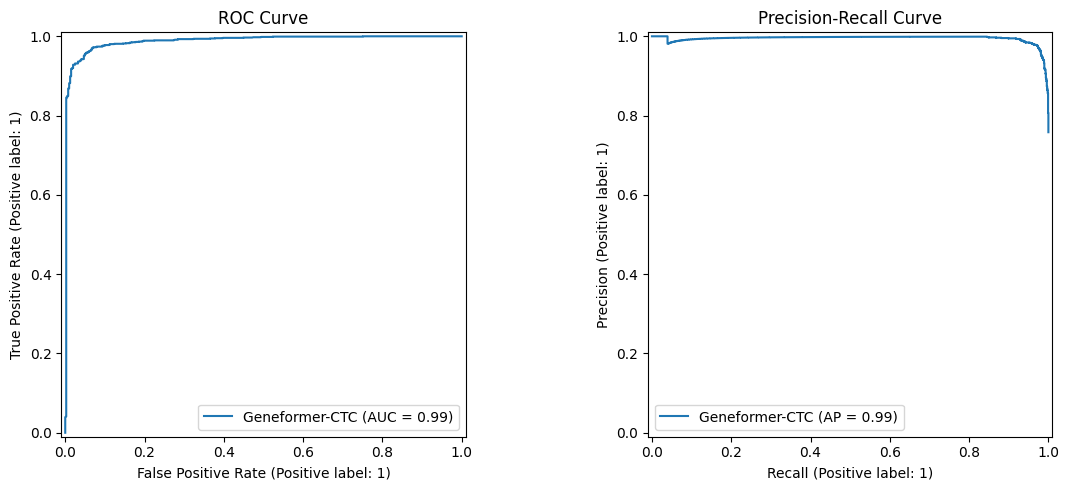

Saved to results/figures/roc_pr_curves.png


In [20]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

test_result  = trainer.predict(test_ds)
probs        = torch.softmax(torch.tensor(test_result.predictions), dim=-1).numpy()[:, 1]
labels       = test_result.label_ids
preds        = (probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
auroc       = roc_auc_score(labels, probs)
auprc       = average_precision_score(labels, probs)
sensitivity = tp / max(tp+fn, 1)
specificity = tn / max(tn+fp, 1)

print('=== TEST SET RESULTS ===')
print(f'AUROC:       {auroc:.4f}')
print(f'AUPRC:       {auprc:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

if sensitivity < 0.7:
    print('WARNING: Sensitivity below 0.7 — model missing too many CTCs')

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(labels, probs, ax=axes[0], name='Geneformer-CTC')
PrecisionRecallDisplay.from_predictions(labels, probs, ax=axes[1], name='Geneformer-CTC')
axes[0].set_title('ROC Curve')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('results/figures/roc_pr_curves.png', dpi=150)
plt.show()
print('Saved to results/figures/roc_pr_curves.png')

## 10. EpCAM subgroup analysis

In [21]:
# Get epcam status for test cells
test_epcam = [str(full_ds[i]['epcam_status']) for i in test_idx]

results_df = pd.DataFrame({
    'label':        labels,
    'prob':         probs,
    'pred':         preds,
    'epcam_status': test_epcam,
})

print('=== EPCAM SUBGROUP ANALYSIS ===')
for status in results_df['epcam_status'].unique():
    subset = results_df[results_df['epcam_status'] == status]
    ctc_subset = subset[subset['label'] == 1]
    if len(ctc_subset) == 0:
        continue
    detected = (ctc_subset['pred'] == 1).sum()
    sensitivity_sub = detected / len(ctc_subset)
    print(f'\nEpCAM status: {status}')
    print(f'  CTC cells:   {len(ctc_subset)}')
    print(f'  Detected:    {detected}')
    print(f'  Sensitivity: {sensitivity_sub:.4f}')

=== EPCAM SUBGROUP ANALYSIS ===

EpCAM status: low
  CTC cells:   1251
  Detected:    1169
  Sensitivity: 0.9345

EpCAM status: high
  CTC cells:   18
  Detected:    12
  Sensitivity: 0.6667


## 11. UMAP visualization

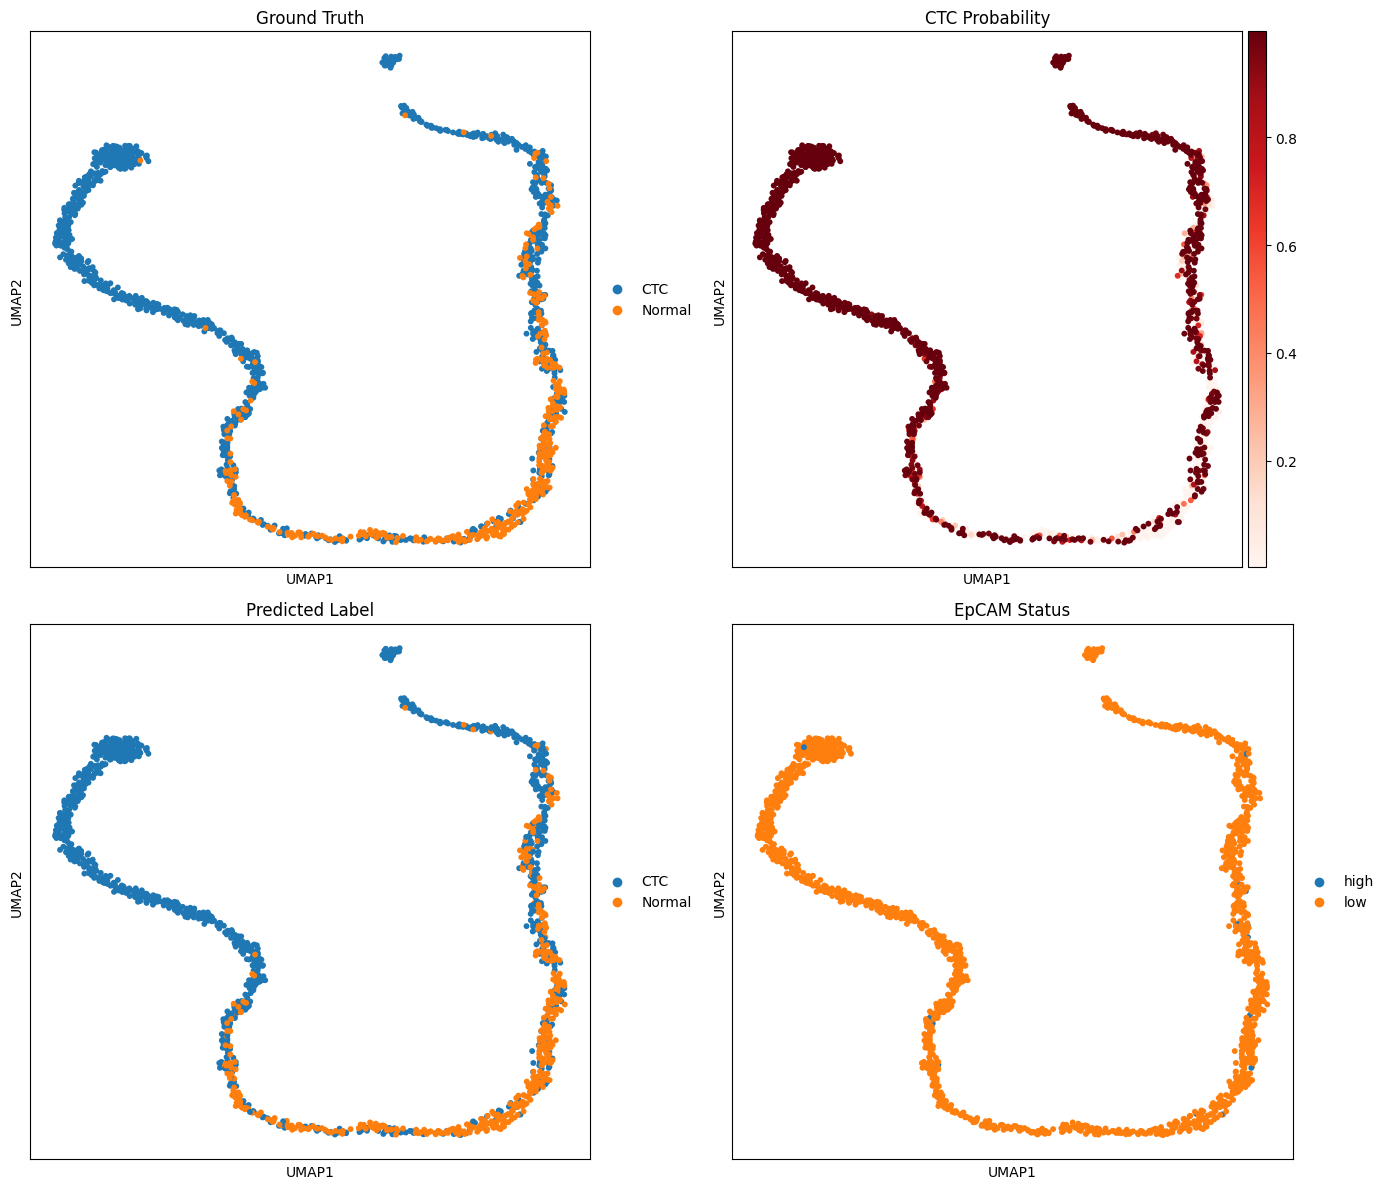

Saved to results/figures/umap_predictions.png


In [22]:
import scanpy as sc
import seaborn as sns

# Build anndata from test set for UMAP
test_input_ids = np.array(test_ds['input_ids'])

adata_test = sc.AnnData(
    X=test_input_ids.astype(np.float32),
)
adata_test.obs['true_label']   = ['CTC' if l == 1 else 'Normal' for l in labels]
adata_test.obs['ctc_prob']     = probs
adata_test.obs['predicted']    = ['CTC' if p == 1 else 'Normal' for p in preds]
adata_test.obs['uncertain']    = ((probs >= 0.4) & (probs <= 0.6)).astype(str)
adata_test.obs['epcam_status'] = test_epcam

sc.pp.pca(adata_test, n_comps=50)
sc.pp.neighbors(adata_test)
sc.tl.umap(adata_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sc.pl.umap(adata_test, color='true_label',   ax=axes[0,0], show=False, title='Ground Truth')
sc.pl.umap(adata_test, color='ctc_prob',     ax=axes[0,1], show=False, title='CTC Probability', cmap='Reds')
sc.pl.umap(adata_test, color='predicted',    ax=axes[1,0], show=False, title='Predicted Label')
sc.pl.umap(adata_test, color='epcam_status', ax=axes[1,1], show=False, title='EpCAM Status')
plt.tight_layout()
plt.savefig('results/figures/umap_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/figures/umap_predictions.png')

## 12. Save checkpoint to Google Drive

In [23]:
import shutil

trainer.save_model('results/checkpoints/best_model')

# Copy checkpoint and results to Drive
!cp -r results/checkpoints/best_model /content/drive/MyDrive/ctc_detect_checkpoint
!cp -r results/figures /content/drive/MyDrive/ctc_detect_figures

print('Checkpoint saved to Google Drive: ctc_detect_checkpoint/')
print('Figures saved to Google Drive: ctc_detect_figures/')
print('Done!')

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in ./Geneformer/Geneformer-V1-10M - will assume that the vocabulary was not modified.
  warnings.warn(


Checkpoint saved to Google Drive: ctc_detect_checkpoint/
Figures saved to Google Drive: ctc_detect_figures/
Done!


In [24]:
trainer.save_model('results/checkpoints/best_model')
!cp -r results/checkpoints/best_model /content/drive/MyDrive/ctc_detect_checkpoint
!cp -r results/figures /content/drive/MyDrive/ctc_detect_figures
print('saved')

saved
